In [12]:
import pandas as pd
import numpy as np

In [13]:
#See data.py to find all the imports packages
from data import spt_dol_import

spt_dol = spt_dol_import()
#spt_dol.info()
#spt_dol.head()

#Importing PPP
from data import PPP_import
import pandas as pd

df_PPP = PPP_import()
df_PPP.head()

CURRENCY,AUD,BRL,CAD,CHF,CLP,CZK,EUR,GBP,HUF,IDR,...,INR,JPY,MXN,NOK,NZD,PLN,RUB,SEK,SGD,ZAR
TIME_PERIOD,,,,,,,,,,,,,,,,,,,,,
1998-01-01,1.300774,0.689104,1.184866,1.827602,281.901592,13.986306,0.862638,0.720671,97.816595,1045.728708,...,9.392232,166.393737,4.954420,9.311803,1.449162,1.654902,3.258399,9.395336,0.972681,2.451477
1999-01-01,1.296950,0.733919,1.190810,1.802836,284.049363,14.229350,0.865406,0.725819,104.545883,1177.158453,...,9.545346,162.035740,5.633670,9.283739,1.434660,1.737656,5.539641,9.305900,0.924793,2.583792
2000-01-01,1.312261,0.757895,1.228197,1.788660,290.423477,14.327536,0.860905,0.704372,110.049076,1386.451585,...,9.674133,154.687365,6.078239,9.083460,1.444868,1.832541,7.301404,9.161129,0.939247,2.758554
2001-01-01,1.328086,0.802171,1.220053,1.768621,296.176351,14.323590,0.863926,0.694551,114.418570,1549.758991,...,9.765331,149.639771,6.329170,9.175302,1.473448,1.837258,8.322817,9.402445,0.901897,2.908249
2002-01-01,1.336490,0.867291,1.229333,1.709760,301.387054,14.458321,0.866973,0.689877,118.141282,1616.020707,...,9.973197,143.774205,6.553697,9.056730,1.468962,1.799795,9.273504,9.413655,0.880130,3.222802


Now that we have the exchange rates in dollars (direct quote), we need the PPP ones such that we can compute $Qt = St(usd/f) * Pf/Pusd$

- If $Qt > 1$ then $St*Pf > Pusd$ => domestic prices are lower in real term => domestic competitiveness is enhanced => we can expect the exchange rate $St$ to decrease in order to get back to equilibrium : therefore we __short__ the foreign currency.
- If $Qt < 1$ => we go __long__ the foreign currency

$Pf/Pusd$ is given by the PPP database below (per dollar data)

In [14]:
#Croatia(Kuna) and Bulgaria(Levi) swithced to € recently so we drop them from the analysis
#df_corabulg = pd.read_csv("/Users/hirecheariles/Documents/Cours/Master Finance/International Finance/Project/CroaBulg.csv", sep =";")
#df_corabulg = df_corabulg[["TIME_PERIOD", "CURRENCY", "OBS_VALUE"]]
#df_corabulg

We match the order of the columns in the two dataframes

In [15]:
mapping = {'AUSTDOL(ER)': "AUD", 'BRACRUZ(ER)':'BRL', 'CNDOLLR(ER)':'CAD', 'CHILPES(ER)':'CLP',
       'USEURSP(ER)':"EUR", 'HUNFORT(ER)':"HUF", 'INDRUPE(ER)':"INR", 'INDORUP(ER)':"IDR",
       'ISRSHEK(ER)':"ILS", 'JAPAYEN(ER)':"JPY", 'MEXPESO(ER)':"MXN", 'NZDOLLR(ER)':"NZD",
       'NORKRON(ER)':"NOK", 'POLZLOT(ER)':"PLN", 'CISRUBM(ER)':"RUB", 'SINGDOL(ER)':"SGD",
       'COMRAND(ER)':"ZAR", 'SWEKRON(ER)':"SEK", 'SWISSFR(ER)':"CHF", 'CZECHCM(ER)':"CZK", 'GBP(ER)':"GBP"}
spt_dol = spt_dol.rename(columns=mapping)

We build the strategy with both monthly and quarterly rebalancement

In [16]:
#We rebalance on the median date to avoid any noise from month beginning
rebal_mth = spt_dol.index.to_series().groupby(spt_dol.index.to_period("M")).min() #Monthly rebalancement
rebal_qtr = spt_dol.index.to_series().groupby(spt_dol.index.to_period('Q')).min() #Quarterly rebalancement
rebal_qmed = spt_dol.index.to_series().groupby(spt_dol.index.to_period("Q")).median().dt.normalize() #Quarterly median date

Note that sometimes, the median date won't be a tradable one, but the trade would occur at the opening of the next trading session in any case

In [17]:
#We reindex the data to get a dataframe with observations at the right intervals
spt_mth = spt_dol.reindex(rebal_mth, method="ffill")
spt_qtr = spt_dol.reindex(rebal_qtr, method ="ffill")
spt_qmed = spt_dol.reindex(rebal_qmed, method="ffill")

df_PPPm = df_PPP.reindex(rebal_mth, method='ffill')
df_PPPq = df_PPP.reindex(rebal_qtr, method="ffill")
df_PPPqmed = df_PPP.reindex(rebal_qmed, method="ffill")

#Computing the Real Exchange Rate Qt for the different periods
df_RERm = spt_mth * df_PPPm 
df_RERq = spt_qtr * df_PPPq
df_RERqmed = spt_qmed * df_PPPqmed

df_RERq.tail()

,AUD,BRL,CAD,CHF,CLP,CZK,EUR,GBP,HUF,IDR,...,INR,JPY,MXN,NOK,NZD,PLN,RUB,SEK,SGD,ZAR
Code,,,,,,,,,,,,,,,,,,,,,
2023-10-02,0.852180,0.482645,0.834015,1.086890,0.478919,0.540455,0.685820,0.800845,0.457067,0.310350,...,0.244341,0.626192,0.555199,0.824180,0.869998,0.437196,0.274726,0.772245,0.580720,0.381744
2024-01-01,0.932449,0.512048,0.872496,1.155915,0.499011,0.573756,0.722325,0.846662,0.507443,0.308366,...,0.245416,0.670043,0.585583,0.900197,0.926887,0.495753,0.325089,0.842489,0.609558,0.406393
2024-04-01,0.887206,0.492279,0.847647,1.075211,0.442036,0.544851,0.702577,0.834342,0.478503,0.298799,...,0.244861,0.622899,0.595847,0.833674,0.871087,0.487616,0.314364,0.786124,0.594607,0.391669
2024-07-01,0.908802,0.445051,0.837848,1.076170,0.463267,0.548089,0.701597,0.839788,0.477411,0.290890,...,0.244740,0.584293,0.538351,0.856350,0.888664,0.485324,0.334537,0.798411,0.592213,0.407451
2024-10-01,0.941327,0.455149,0.851994,1.151034,0.484253,0.561542,0.724287,0.882493,0.488242,0.312362,...,0.243645,0.657818,0.502537,0.863466,0.921163,0.503266,0.307544,0.827571,0.624000,0.428168


We compute the results of our analysis in sample first until 2015 and then OOS from 2015-2025.

In [18]:
spt_IS = spt_dol[:"2015"]
spt_OS = spt_dol["2015":]

df_RERmIS = df_RERm[:"2015"]
df_RERmOS = df_RERm["2015":]

df_RERqIS = df_RERq[:"2015"]
df_RERqOS = df_RERq["2015":]

df_RERqmedIS = df_RERqmed[:"2015"]
df_RERqmedOS = df_RERqmed["2015":]

rebal_mIS = rebal_mth[:"2015"]
rebal_qIS = rebal_qtr[:"2015"]
rebal_qmedIS = rebal_qmed[:"2015"]

rebal_mOS = rebal_mth["2015":]
rebal_qOS = rebal_qtr["2015":]
rebal_qmedOS = rebal_qmed["2015":]

In [19]:
from data import weightsPPPstrat

weights_mIS = weightsPPPstrat(df_RERmIS, n_long=7)
weights_qIS = weightsPPPstrat(df_RERqIS, n_long=7)
weights_qmedIS = weightsPPPstrat(RERdf = df_RERqmedIS, n_long=7, rebal_dates=rebal_qmedIS)

monthly_retIS = np.log(spt_IS) - np.log(spt_IS.shift())
quarter_retIS = np.log(spt_IS.reindex(rebal_qIS)) - np.log(spt_IS.reindex(rebal_qIS).shift()) #Quarterly log returns
qmed_retIS = np.log(spt_IS.reindex(rebal_qmedIS, method="ffill")) - np.log(spt_IS.reindex(rebal_qmedIS, method="ffill").shift(1))

returns_mIS = (weights_mIS * monthly_retIS).sum(axis=1)
returns_qIS = (weights_qIS * quarter_retIS).sum(axis=1)
returns_qmedIS = (weights_qmedIS * qmed_retIS).sum(axis=1)

print(f"SharpeMIS = {12*returns_mIS.mean()/(returns_mIS.std()*np.sqrt(12))}")
print(f"SharpeQIS = {4*returns_qIS.mean()/(returns_qIS.std()*np.sqrt(4))}")
print(f"SharpeQmedIS = {4*returns_qmedIS.mean()/(returns_qmedIS.std()*np.sqrt(4))}")

returns_mIS.describe()

SharpeMIS = -0.03024849486953428
SharpeQIS = -0.35871577094707074
SharpeQmedIS = -0.38832964766939804


count    4696.000000
mean       -0.000008
std         0.000897
min        -0.023376
25%         0.000000
50%         0.000000
75%         0.000000
max         0.014277
dtype: float64

We find negative results... (before transaction cost!) and the less worst of all the strategies is the monthly one, which might not let the time of the negative effect of the bad trading decisions that we are taking to occur.

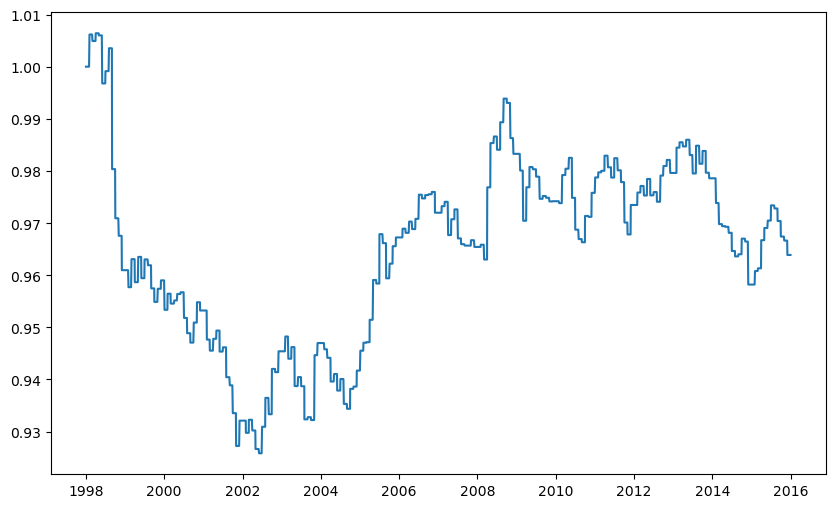

In [20]:
import matplotlib.pyplot as plt

plt.subplots(figsize=(10,6))
plt.plot(returns_mIS.index, np.exp(returns_mIS.cumsum()));

### We now try this PPP Value strategy only on G10 countries, as suggested by DB in 29 March, 2007

EUR (DEM pre-99), JPY, CHF, GBP, NOK, SEK, AUD, NZD, CAD

In [29]:
df_RERG10qIS = df_RERqIS[["AUD", "CAD", "CHF", "EUR", "GBP", "JPY", "NOK", "NZD", "SEK"]]
df_RERG10mIS = df_RERmIS[["AUD", "CAD", "CHF", "EUR", "GBP", "JPY", "NOK", "NZD", "SEK"]]

weightsG10qIS = weightsPPPstrat(df_RERG10qIS) #Calling the function to copmute weights
weightsG10mIS = weightsPPPstrat(df_RERG10mIS)

## Quarterly Strategy
spt_G10qIS = spt_dol.reindex(rebal_qIS, method="ffill") #Only keeping quarters
logret_G10qIS = np.log(spt_G10qIS) - np.log(spt_G10qIS.shift(1))

returns_G10qIS =(logret_G10qIS * weightsG10qIS).sum(axis=1) #Total on each qtr

#Monthly strategy
spt_G10mIS = spt_dol.reindex(rebal_mIS, method="ffill")
logret_G10mIS = np.log(spt_G10mIS) - np.log(spt_G10mIS.shift(1))

returns_G10mIS =(logret_G10mIS * weightsG10mIS).sum(axis=1) 

print(f"Sharpe q= {(4*returns_G10qIS.mean())/(np.sqrt(4)*returns_G10qIS.std())}")
print(f"Sharpe m= {(12*returns_G10mIS.mean())/(np.sqrt(12)*returns_G10mIS.std())}")

print(returns_G10qIS.describe(), returns_G10mIS.describe())
import scipy.stats as sps
print(f'Skew qtr={sps.skew(returns_G10qIS).round(6)}\nKurtosis qtr={sps.kurtosis(returns_G10qIS, fisher=True).round(6)}')
print(f'Skew mth={sps.skew(returns_G10mIS).round(6)}\nKurtosis mth={sps.kurtosis(returns_G10mIS, fisher=True).round(6)}')


Sharpe q= 0.3813361267313416
Sharpe m= 0.3166860259421145
count    72.000000
mean      0.007022
std       0.036829
min      -0.085912
25%      -0.017164
50%       0.003947
75%       0.032795
max       0.086694
dtype: float64 count    216.000000
mean       0.001983
std        0.021689
min       -0.059116
25%       -0.009825
50%        0.000630
75%        0.016143
max        0.063723
dtype: float64
Skew qtr=-0.021421
Kurtosis qtr=-0.275569
Skew mth=-0.098576
Kurtosis mth=0.515365


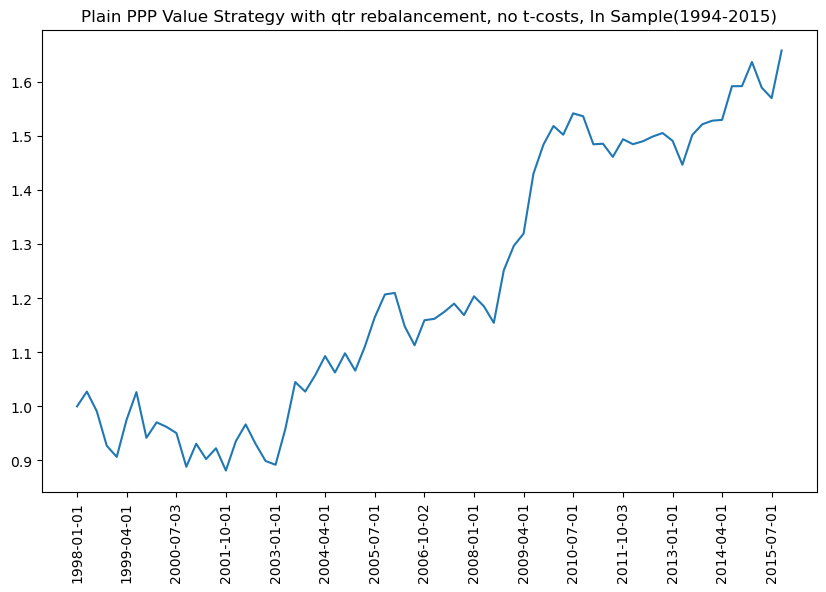

In [24]:
import matplotlib.pyplot as plt
ax, plt.subplots(figsize=(10,6))
plt.plot(returns_G10qIS.index, np.exp(returns_G10qIS.cumsum()), ax=ax)
plt.xticks(returns_G10qIS.index[::5], rotation = 90)
plt.title("Plain PPP Value Strategy with qtr rebalancement, no t-costs, In Sample(1994-2015)")
plt.plot(returns_G10qIS.index, np.exp(returns_G10qIS.cumsum()), ax=ax)
plt.show()

### We can get more precisions of the PPP spot rate within a year using CPI differential to modelise intra-year evolution